In [ ]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import seaborn as sns

# Publication-quality plot styling
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]
plt.rcParams["font.size"] = 15
plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600

os.makedirs("/content/results", exist_ok=True)
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1239s 7us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


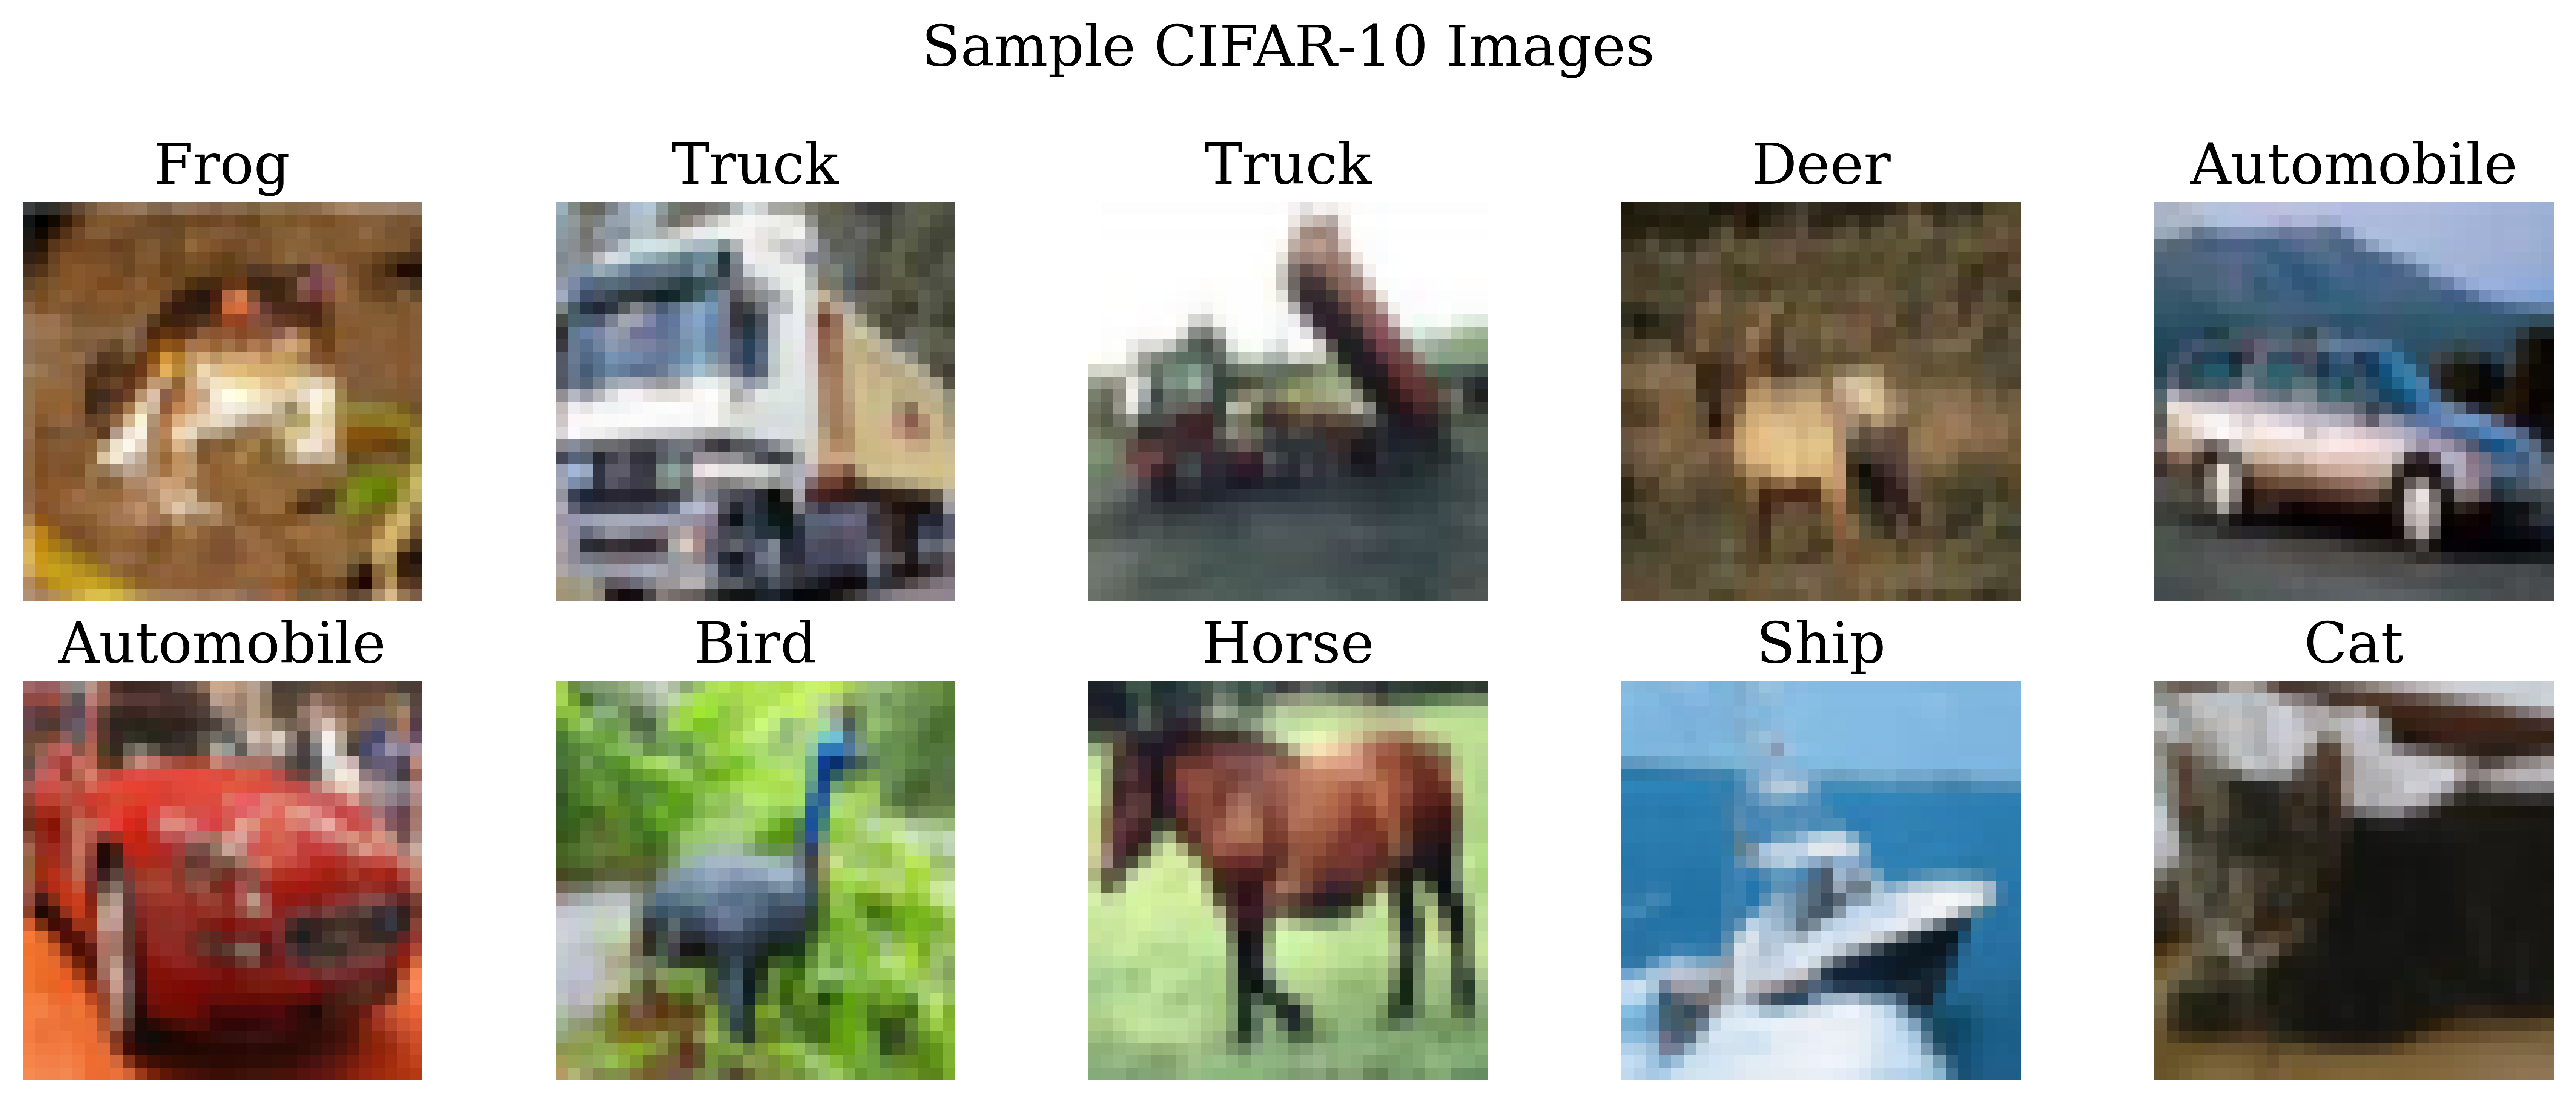

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig("/content/results/01_sample_images.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
IMG_SIZE = 96

def preprocess_ds(x, y, batch_size=32, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(10000)
    def _map(img, label):
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = preprocess_input(img)
        return img, label
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 32
train_ds = preprocess_ds(x_train, y_train_cat, BATCH_SIZE, shuffle=True)
test_ds = preprocess_ds(x_test, y_test_cat, BATCH_SIZE, shuffle=False)

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze convolutional base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.summary()
total_params = model.count_params()
print("Total Parameters:", total_params)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Total Parameters: 14848586


In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_INITIAL = 10  # set 10-20 as per manual

start = time.time()
history_initial = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_INITIAL
)
train_time_initial = time.time() - start
print(f"Initial training time: {train_time_initial:.2f} seconds")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 54ms/step - accuracy: 0.7409 - loss: 0.8722 - val_accuracy: 0.8080 - val_loss: 0.5732
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 62ms/step - accuracy: 0.8113 - loss: 0.5517 - val_accuracy: 0.8102 - val_loss: 0.5503
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.8309 - loss: 0.4924 - val_accuracy: 0.8237 - val_loss: 0.5165
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.8426 - loss: 0.4519 - val_accuracy: 0.8248 - val_loss: 0.5339
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.8530 - loss: 0.4204 - val_accuracy: 0.8236 - val_loss: 0.5277
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.8654 - loss: 0.3876 - val_accuracy: 0.8253 - val_loss: 0.5474
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.8742 - loss: 0.3651 - val_accuracy: 0.8287 - val_loss: 0.5526
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 59ms/step - accuracy: 0.8790 

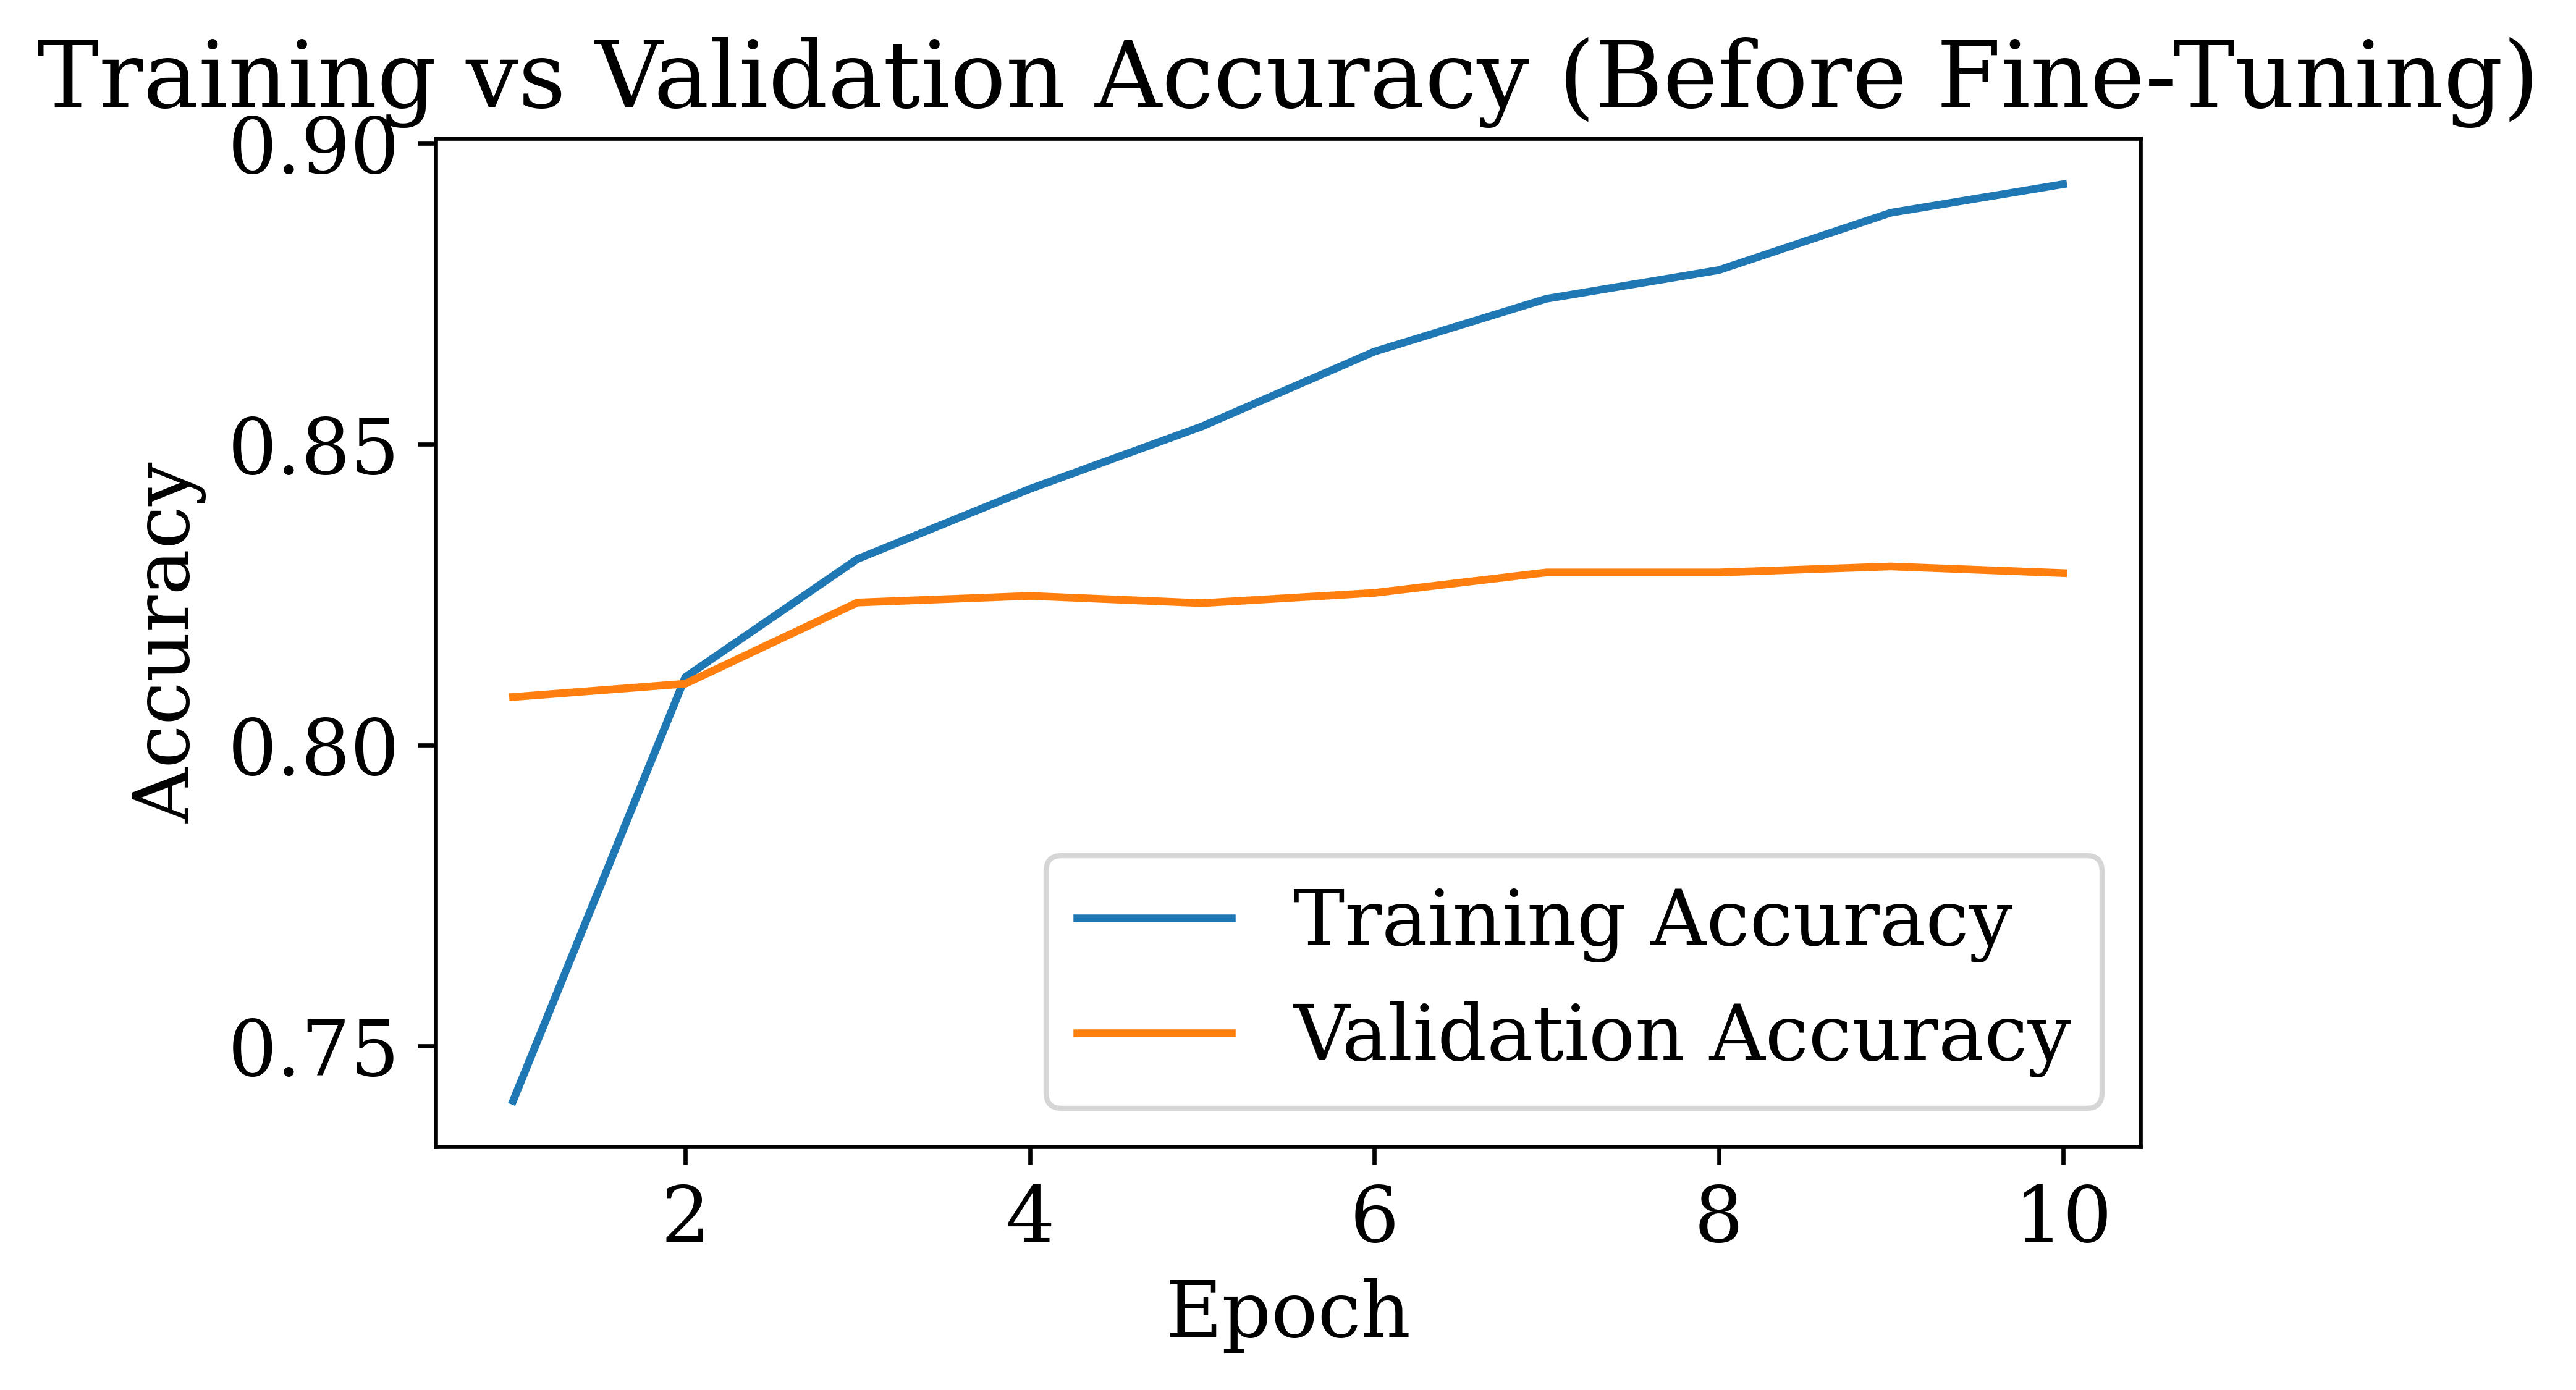

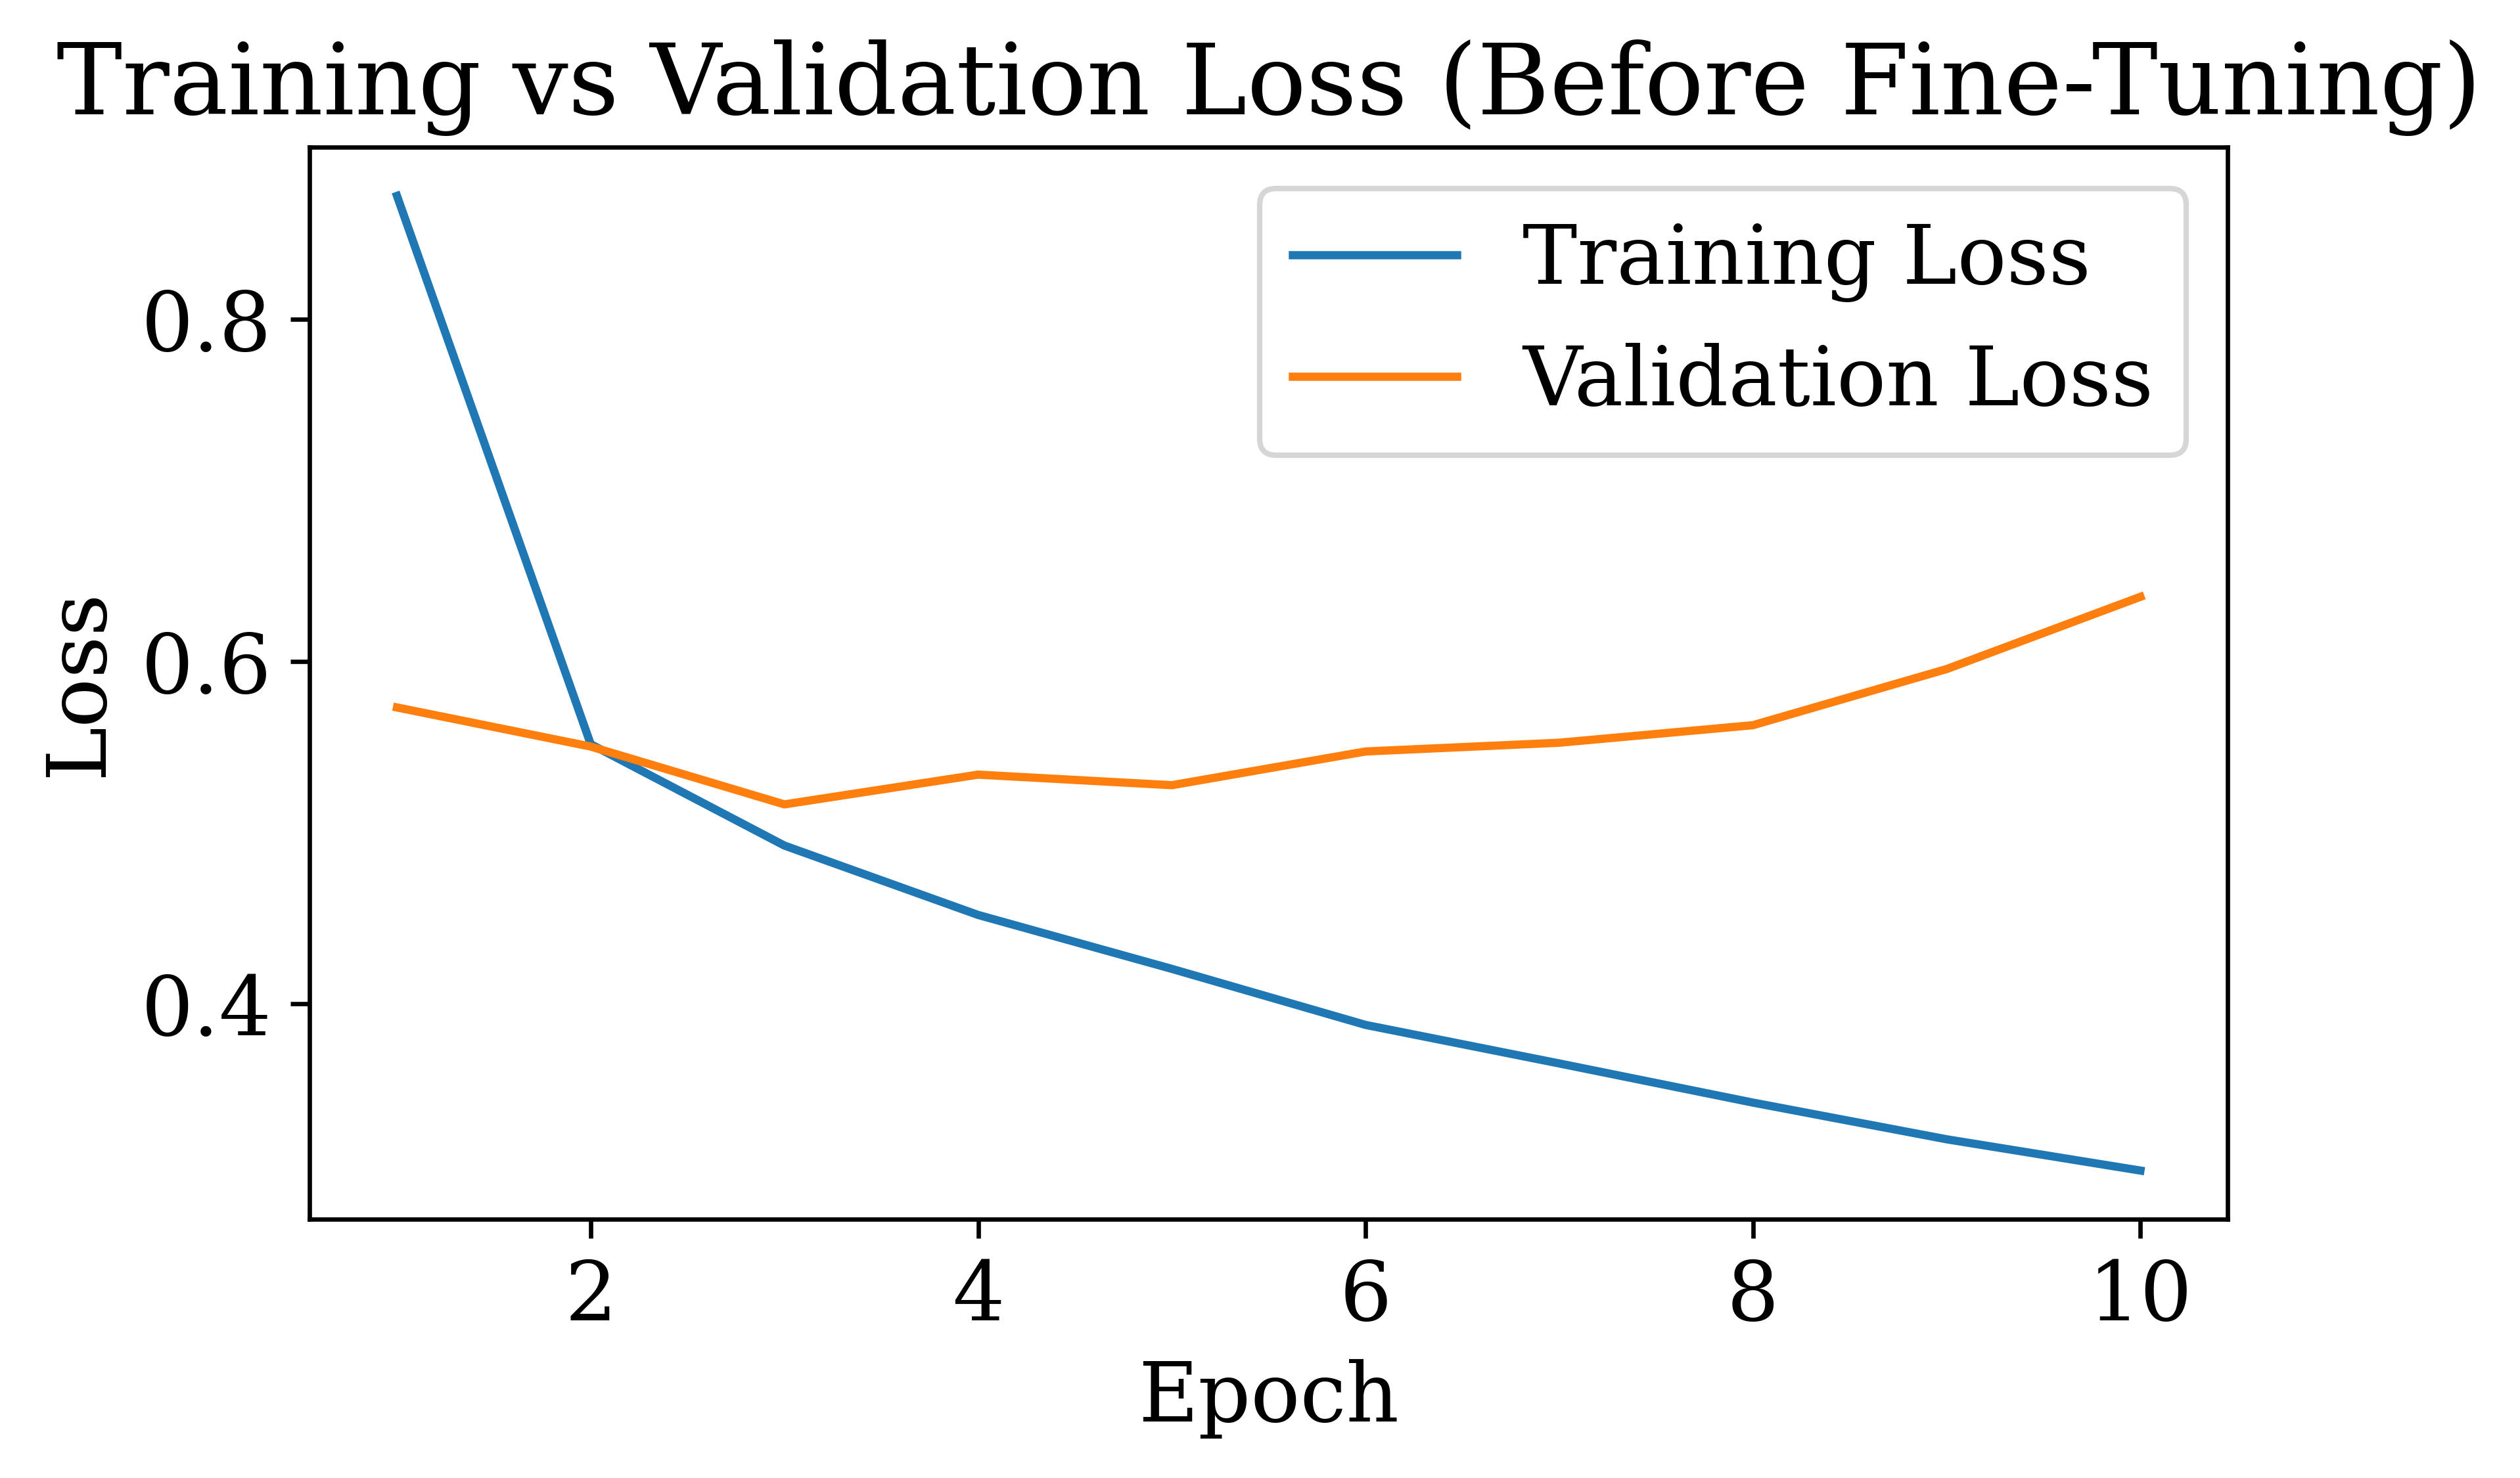

In [ ]:
def plot_history(history, prefix, title_suffix=""):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'Training vs Validation Accuracy {title_suffix}')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
    plt.tight_layout()
    plt.savefig(f"/content/results/{prefix}_accuracy.pdf", dpi=600, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'Training vs Validation Loss {title_suffix}')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    plt.savefig(f"/content/results/{prefix}_loss.pdf", dpi=600, bbox_inches="tight")
    plt.show()

plot_history(history_initial, "02_initial", "(Before Fine-Tuning)")


In [ ]:
base_model.trainable = True
for layer in base_model.layers:
    if not layer.name.startswith('block5'):
        layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FINETUNE = 5  # set 5-10 as per manual

start = time.time()
history_finetune = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_FINETUNE
)
train_time_finetune = time.time() - start
print(f"Fine-tuning time: {train_time_finetune:.2f} seconds")

total_train_time = train_time_initial + train_time_finetune
print(f"Total training time: {total_train_time:.2f} seconds")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 128s 78ms/step - accuracy: 0.9128 - loss: 0.2497 - val_accuracy: 0.8533 - val_loss: 0.5250
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 116s 74ms/step - accuracy: 0.9440 - loss: 0.1557 - val_accuracy: 0.8684 - val_loss: 0.4995
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 116s 74ms/step - accuracy: 0.9578 - loss: 0.1184 - val_accuracy: 0.8751 - val_loss: 0.5099
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 117s 75ms/step - accuracy: 0.9697 - loss: 0.0879 - val_accuracy: 0.8781 - val_loss: 0.5143
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 117s 75ms/step - accuracy: 0.9745 - loss: 0.0709 - val_accuracy: 0.8830 - val_loss: 0.4986
Fine-tuning time: 593.99 seconds
Total training time: 1612.14 seconds


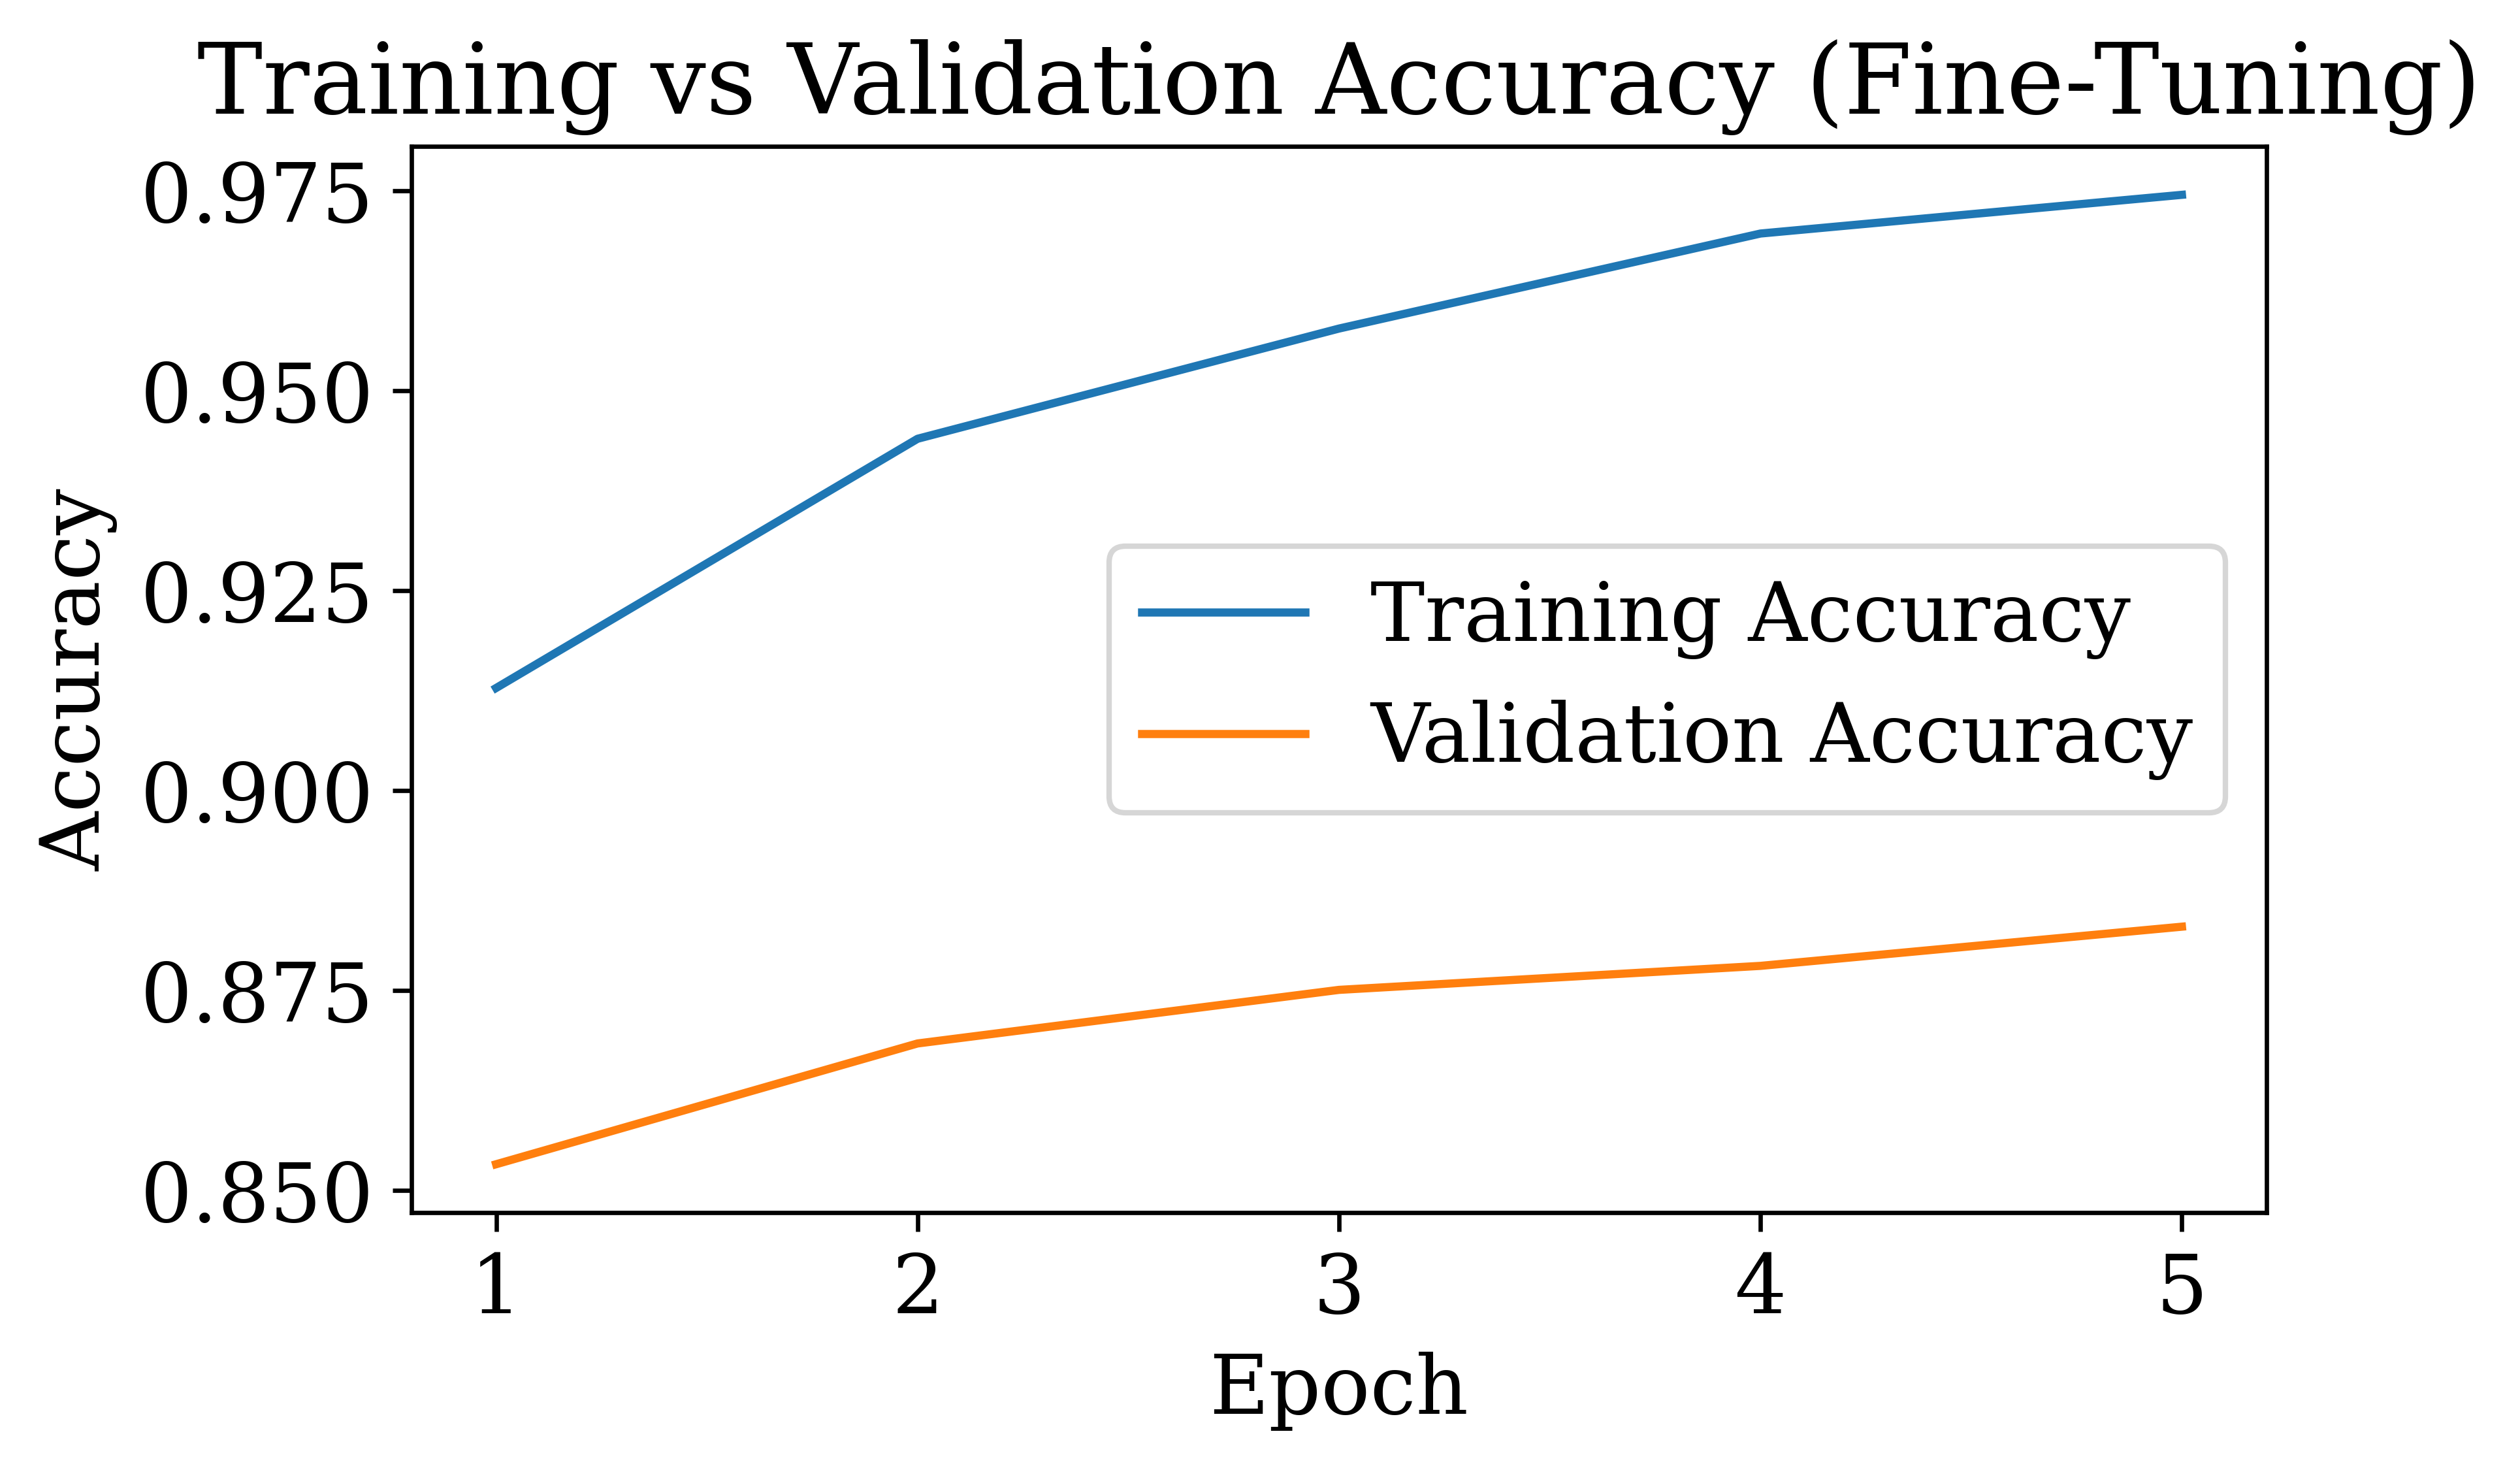

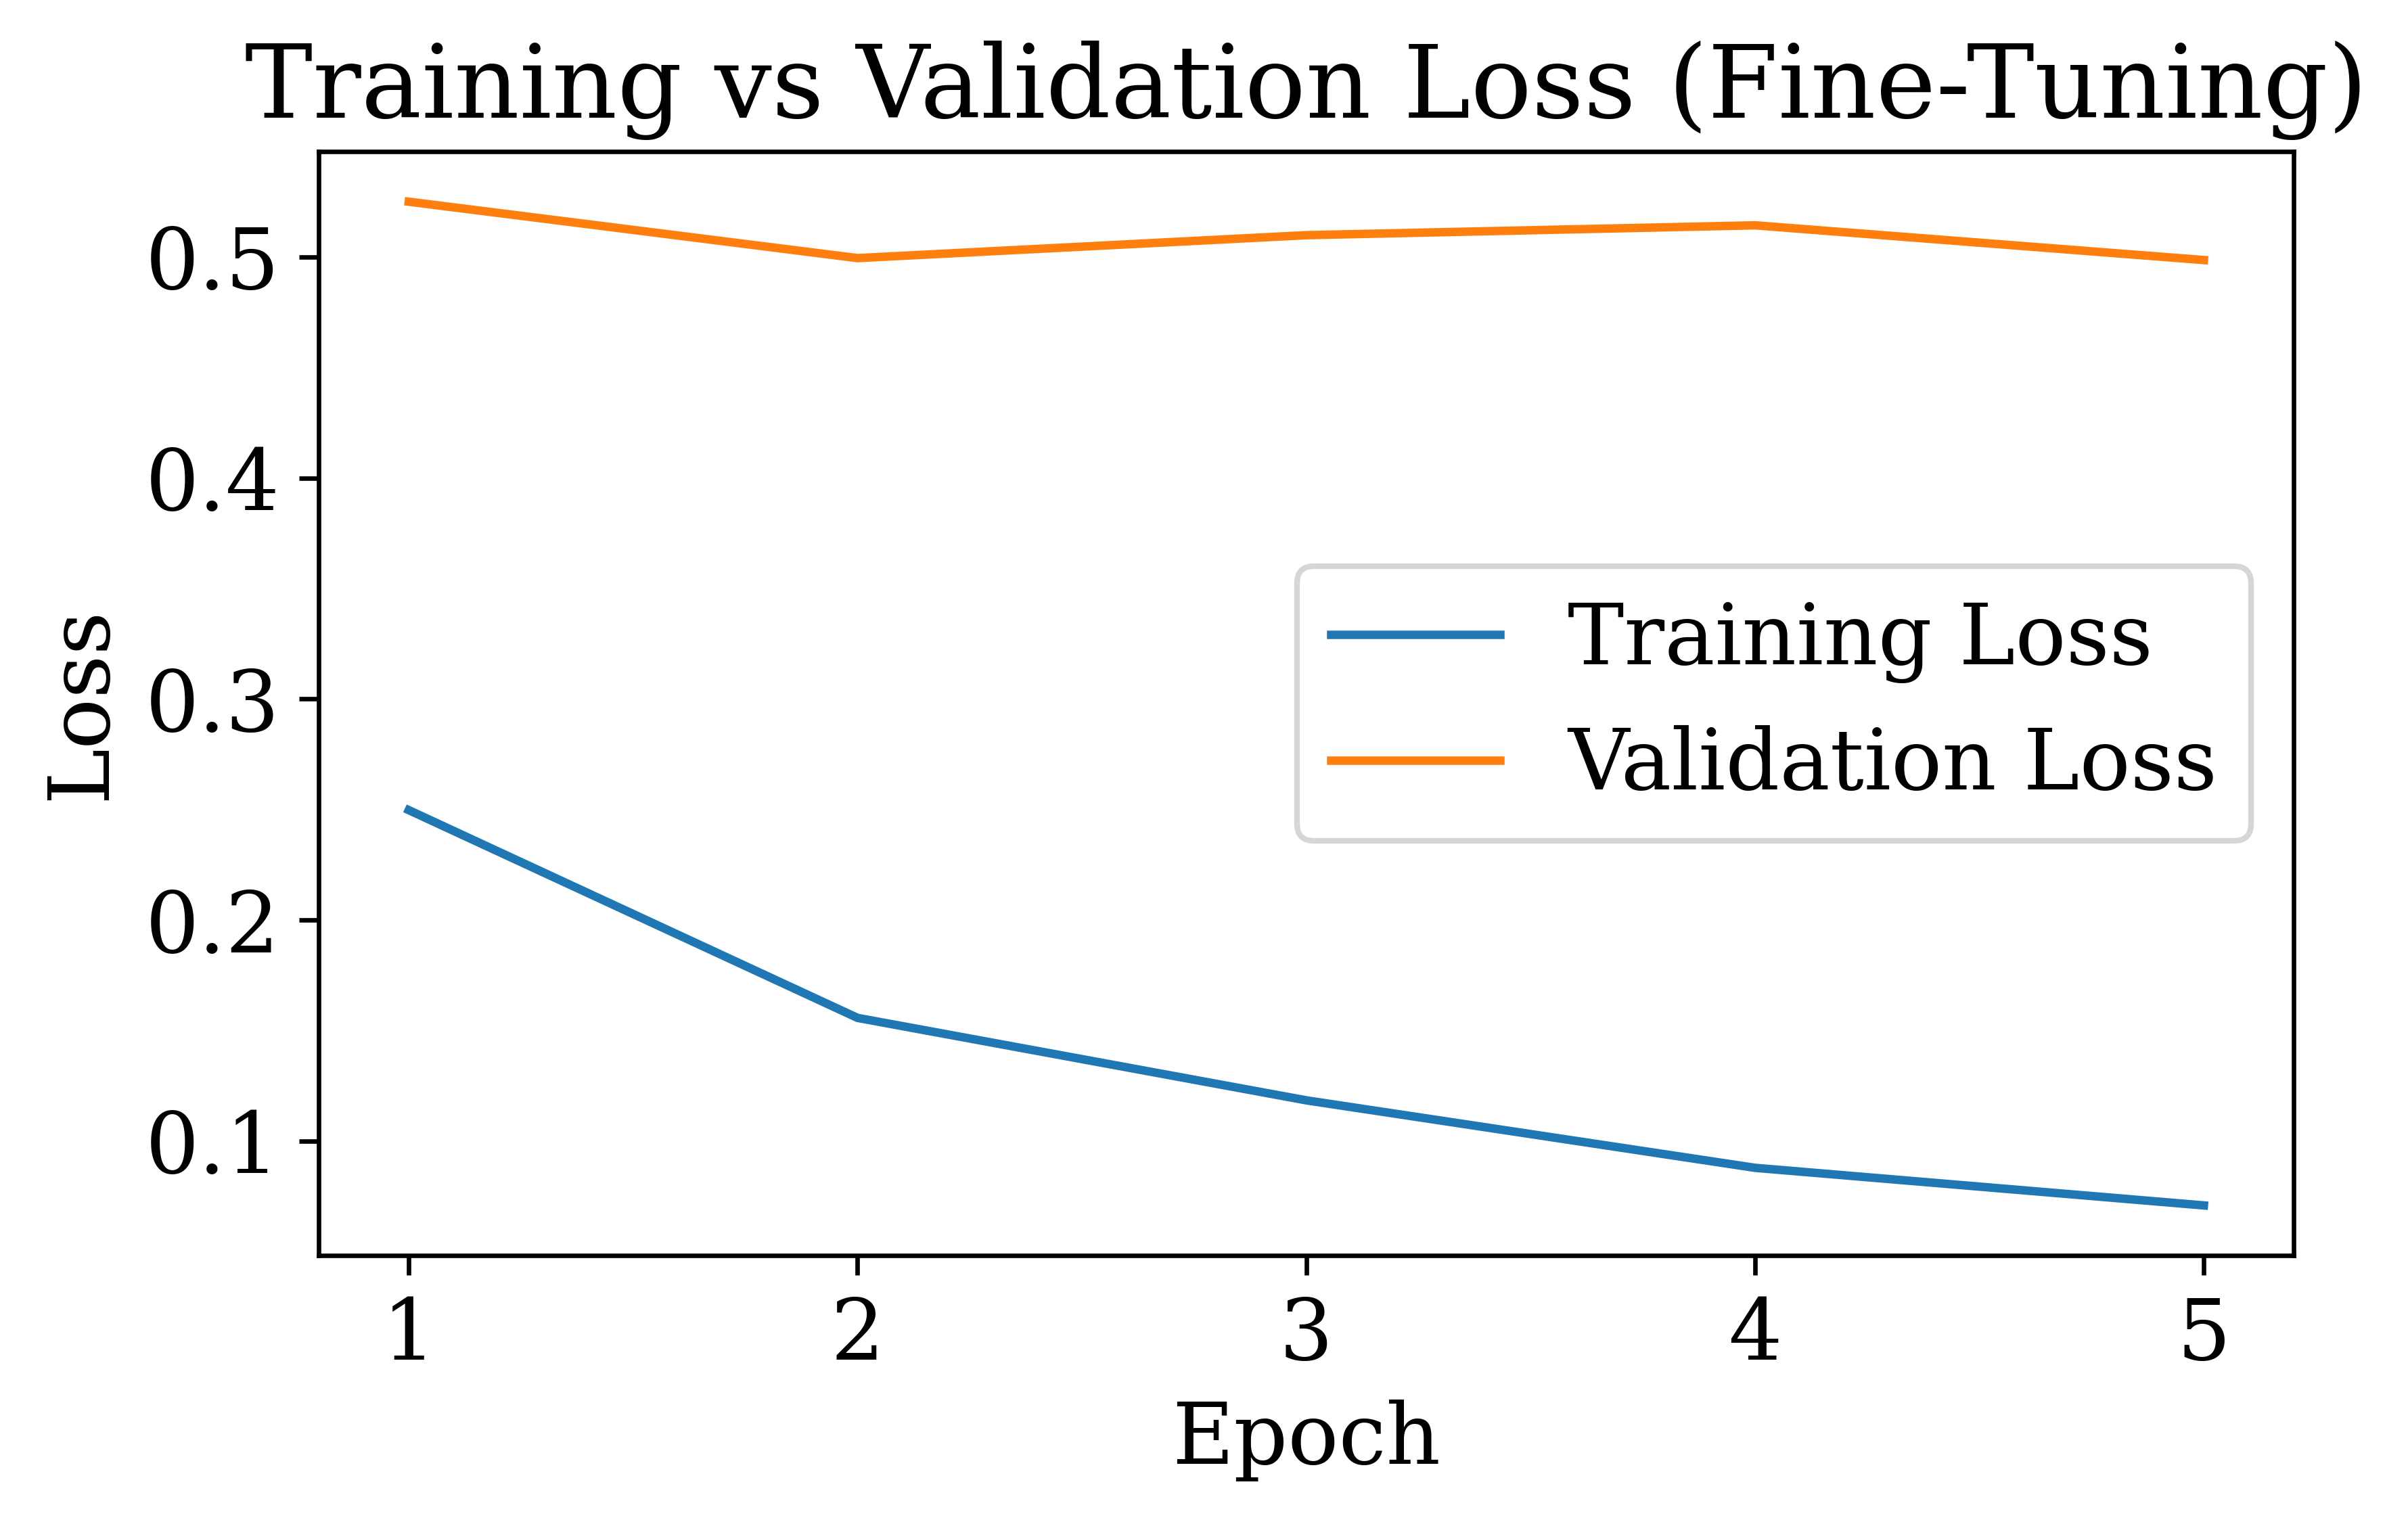

Validation Accuracy BEFORE fine-tuning: 82.86%
Validation Accuracy AFTER fine-tuning:  88.30%


In [ ]:
plot_history(history_finetune, "03_finetune", "(Fine-Tuning)")

acc_before = history_initial.history['val_accuracy'][-1]
acc_after = history_finetune.history['val_accuracy'][-1]
print(f"Validation Accuracy BEFORE fine-tuning: {acc_before*100:.2f}%")
print(f"Validation Accuracy AFTER fine-tuning:  {acc_after*100:.2f}%")

In [ ]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

test_accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Testing Accuracy : {test_accuracy*100:.2f}%")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro)   : {recall:.4f}")
print(f"F1-score (macro) : {f1:.4f}")

print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

with open("/content/results/classification_report.txt", "w") as f:
    f.write(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step
Testing Accuracy : 88.30%
Precision (macro): 0.8837
Recall (macro)   : 0.8830
F1-score (macro) : 0.8832

Classification Report:
              precision    recall  f1-score   support

    Airplane       0.90      0.89      0.90      1000
  Automobile       0.93      0.94      0.94      1000
        Bird       0.88      0.86      0.87      1000
         Cat       0.75      0.79      0.77      1000
        Deer       0.85      0.87      0.86      1000
         Dog       0.82      0.81      0.82      1000
        Frog       0.93      0.91      0.92      1000
       Horse       0.93      0.89      0.91      1000
        Ship       0.92      0.95      0.94      1000
       Truck       0.93      0.92      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



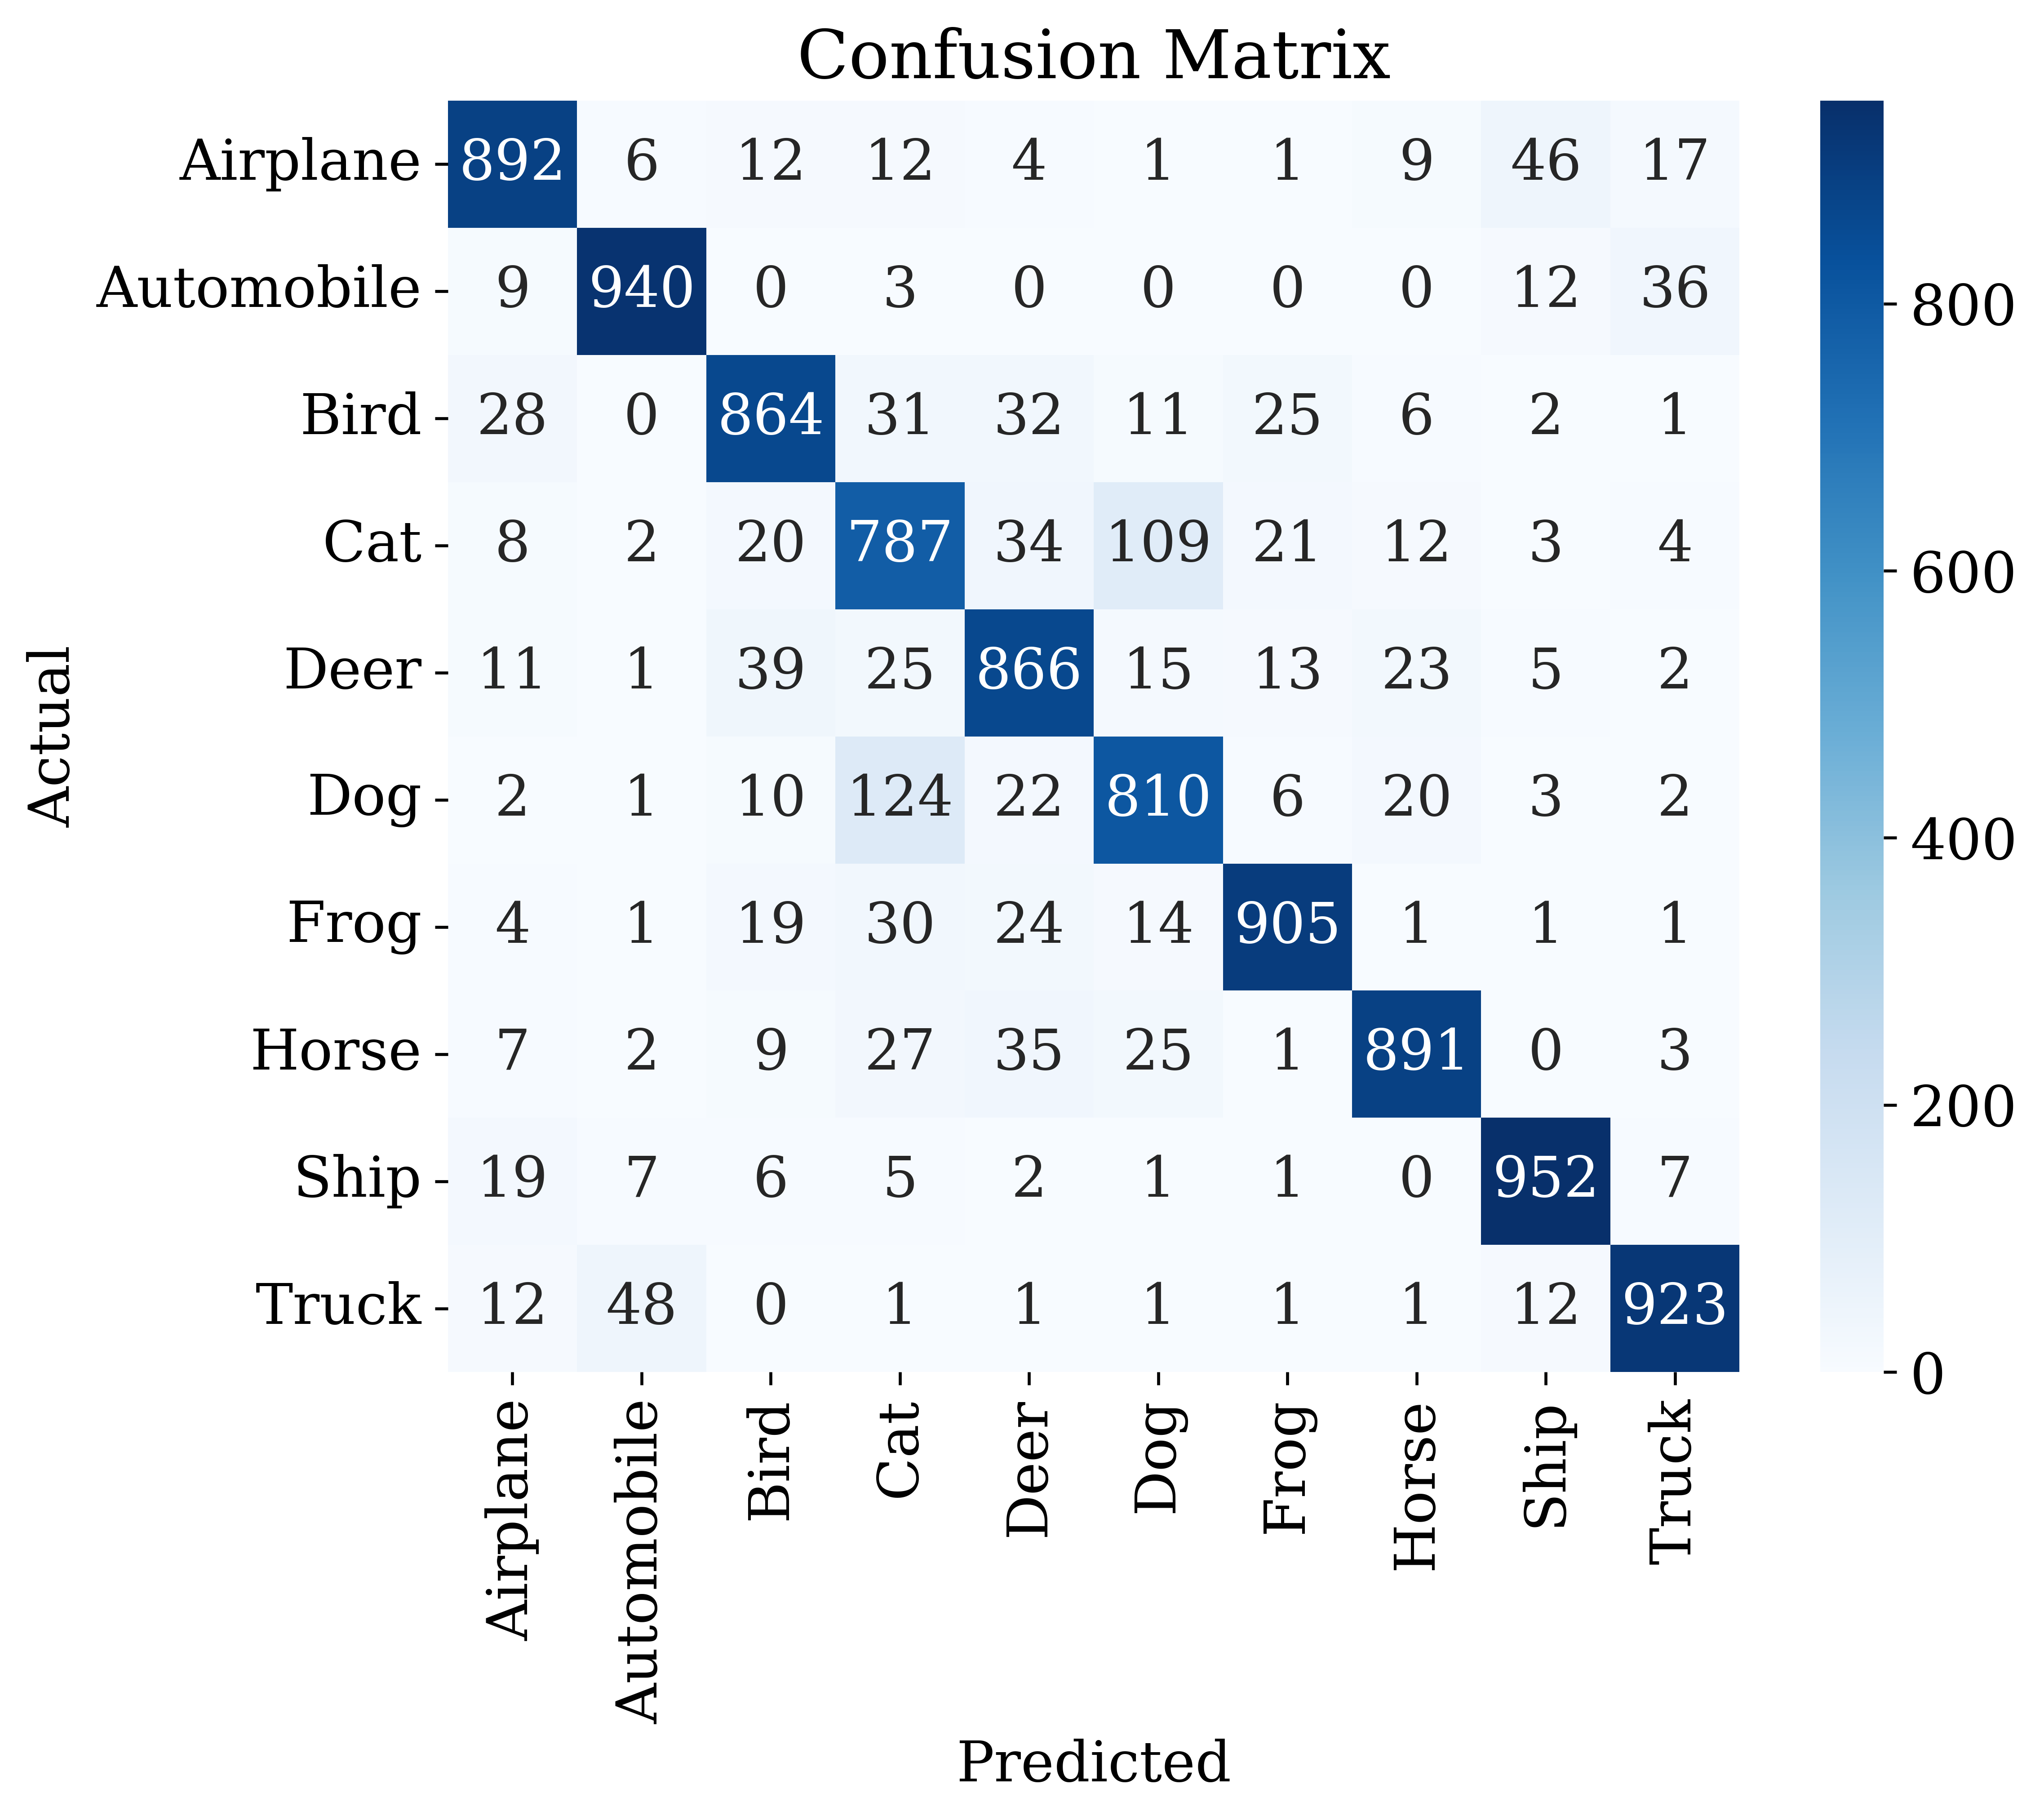

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("/content/results/04_confusion_matrix.pdf", dpi=600, bbox_inches="tight")
plt.show()

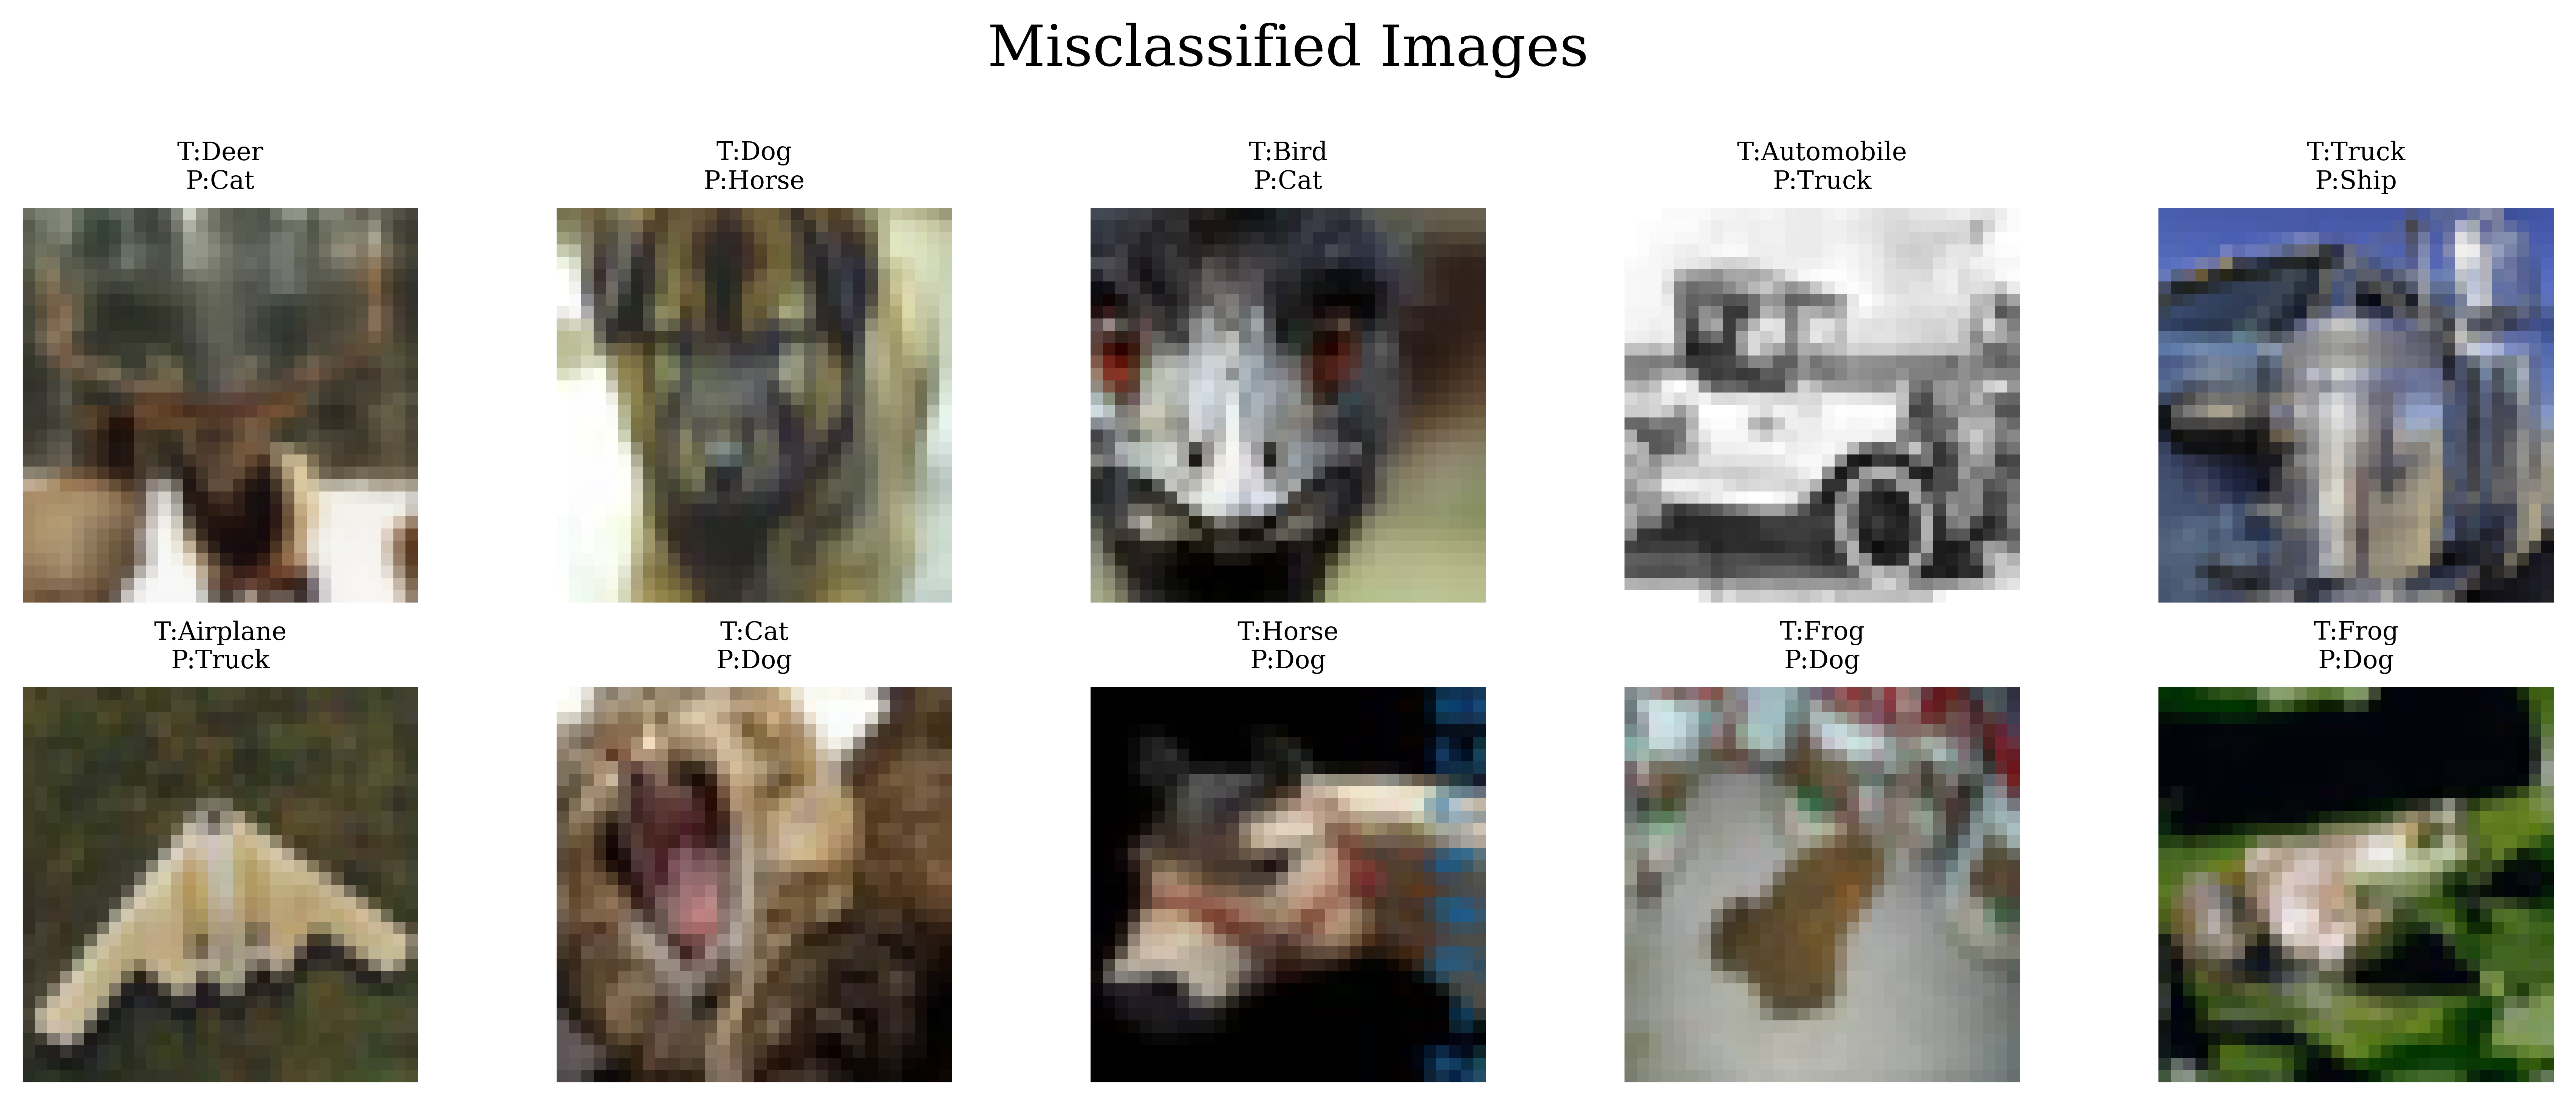

In [ ]:
mis_idx = np.where(y_pred != y_true)[0]
n_show = min(10, len(mis_idx))
if n_show > 0:
    fig, axes = plt.subplots(2, 5, figsize=(12,5))
    for i, ax in enumerate(axes.flat[:n_show]):
        idx = mis_idx[i]
        ax.imshow(x_test[idx])
        ax.set_title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}", fontsize=8)
        ax.axis('off')
    plt.suptitle("Misclassified Images")
    plt.tight_layout()
    plt.savefig("/content/results/05_misclassified.pdf", dpi=600, bbox_inches="tight")
    plt.show()
else:
    print("No misclassified images found in this run.")

In [ ]:
summary = {
    "model": "VGG16 (Transfer Learning)",
    "total_parameters": int(total_params),
    "training_accuracy_initial": float(history_initial.history['accuracy'][-1]),
    "validation_accuracy_initial": float(acc_before),
    "training_accuracy_finetune": float(history_finetune.history['accuracy'][-1]),
    "validation_accuracy_finetune": float(acc_after),
    "testing_accuracy": float(test_accuracy),
    "precision_macro": float(precision),
    "recall_macro": float(recall),
    "f1_macro": float(f1),
    "training_time_seconds_initial": float(train_time_initial),
    "training_time_seconds_finetune": float(train_time_finetune),
    "training_time_seconds_total": float(total_train_time),
    "epochs_initial": EPOCHS_INITIAL,
    "epochs_finetune": EPOCHS_FINETUNE,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate_initial": 0.001,
    "learning_rate_finetune": 1e-5
}

with open("/content/results/summary_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

import shutil
shutil.make_archive("/content/experiment4_results", 'zip', "/content/results")

from google.colab import files
files.download("/content/experiment4_results.zip")

{
  "model": "VGG16 (Transfer Learning)",
  "total_parameters": 14848586,
  "training_accuracy_initial": 0.8932399749755859,
  "validation_accuracy_initial": 0.8285999894142151,
  "training_accuracy_finetune": 0.9745000004768372,
  "validation_accuracy_finetune": 0.8830000162124634,
  "testing_accuracy": 0.883,
  "precision_macro": 0.8837082278736791,
  "recall_macro": 0.883,
  "f1_macro": 0.8832143762303918,
  "training_time_seconds_initial": 1018.156566619873,
  "training_time_seconds_finetune": 593.9862835407257,
  "training_time_seconds_total": 1612.1428501605988,
  "epochs_initial": 10,
  "epochs_finetune": 5,
  "batch_size": 32,
  "optimizer": "Adam",
  "learning_rate_initial": 0.001,
  "learning_rate_finetune": 1e-05
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>